<a href="https://colab.research.google.com/github/Dounia-Awni/Chicago-Crime-Data-Analysis-2001-2022-/blob/main/Chicago_Crime_Data_Analysis_(2001%E2%80%932022).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chicago Crime Data Analysis (2001–2022)

* This notebook analyzes 22 years of crime reports from the City of Chicago (2001–2022, ~7.7 million records) to answer stakeholder questions for a reporter covering crime trends.

##Load data and preprocessing

In [2]:
#Import required libraries
import calendar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from datetime import timedelta
from scipy.stats import linregress
from pandas.tseries.holiday import USFederalHolidayCalendar

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_rows', 40)

In [4]:
#Install holiday library
%pip install holidays

In [3]:
#Mount Google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
#Unzip the Chicago Crime dataset and extracts its contents to a specified directory.
#then list the files found in the output directory to confirm successful extraction.

import zipfile, os, glob

# ── Step 1: Unzip ────────────────────────────
ZIP_FILE   = "/content/drive/MyDrive/AXSOSACADEMY/04-AdvancedML/Week21/Data/Chicago_Crime_2001-2022.zip"   # path to the downloaded zip
OUTPUT_DIR = "/content/Data/Data/"               # folder where CSVs will be extracted

with zipfile.ZipFile(ZIP_FILE, 'r') as zf:
    zf.extractall(OUTPUT_DIR)

print(f"Extracted to: {OUTPUT_DIR}")
print("Files found:", sorted(os.listdir(OUTPUT_DIR)))

Extracted to: /content/Data/Data/
Files found: ['Data']


In [6]:
#loading all individual CSV files into a list of DataFrames and then concatenates them into a single master DataFrame.

crime_files = sorted(glob.glob(OUTPUT_DIR + "Data/Chicago-Crime_*.csv"))
print(f"Found {len(crime_files)} CSV files")

dfs = []
for f in crime_files:
    temp_df = pd.read_csv(f)
    dfs.append(temp_df)
    print(f"  Loaded: {os.path.basename(f)}  →  {len(temp_df):,} rows")

# ── Step 3: Concatenate into one master DataFrame ───────────────────
df = pd.concat(dfs, ignore_index=True)

#Show df info and head
df.info()
df.head()

Found 22 CSV files
  Loaded: Chicago-Crime_2001.csv  →  485,886 rows
  Loaded: Chicago-Crime_2002.csv  →  486,807 rows
  Loaded: Chicago-Crime_2003.csv  →  475,985 rows
  Loaded: Chicago-Crime_2004.csv  →  469,422 rows
  Loaded: Chicago-Crime_2005.csv  →  453,773 rows
  Loaded: Chicago-Crime_2006.csv  →  448,179 rows
  Loaded: Chicago-Crime_2007.csv  →  437,087 rows
  Loaded: Chicago-Crime_2008.csv  →  427,183 rows
  Loaded: Chicago-Crime_2009.csv  →  392,827 rows
  Loaded: Chicago-Crime_2010.csv  →  370,513 rows
  Loaded: Chicago-Crime_2011.csv  →  351,993 rows
  Loaded: Chicago-Crime_2012.csv  →  336,319 rows
  Loaded: Chicago-Crime_2013.csv  →  307,536 rows
  Loaded: Chicago-Crime_2014.csv  →  275,789 rows
  Loaded: Chicago-Crime_2015.csv  →  264,787 rows
  Loaded: Chicago-Crime_2016.csv  →  269,823 rows
  Loaded: Chicago-Crime_2017.csv  →  269,100 rows
  Loaded: Chicago-Crime_2018.csv  →  268,899 rows
  Loaded: Chicago-Crime_2019.csv  →  261,325 rows
  Loaded: Chicago-Crime_2020.cs

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
0,1326041,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE,False,False,1624,16.0,NaN,41.957850,-87.749185
1,1319931,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,RESIDENCE,False,True,825,8.0,NaN,41.783892,-87.684841
2,1324743,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313,3.0,NaN,41.780412,-87.611970
3,1310717,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424,24.0,NaN,42.012391,-87.678032
4,1318099,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214,2.0,NaN,41.819538,-87.620020


In [7]:
#Convert the 'Date' column to datetime objects and sets it as the DataFrame's index.
df['Date'] = pd.to_datetime(df['Date'], format="%m/%d/%Y %I:%M:%S %p")
df = df.sort_values('Date').set_index('Date')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7713109 entries, 2001-01-01 00:00:00 to 2022-12-31 23:55:00
Data columns (total 11 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Primary Type          object 
 2   Description           object 
 3   Location Description  object 
 4   Arrest                bool   
 5   Domestic              bool   
 6   Beat                  int64  
 7   District              float64
 8   Ward                  float64
 9   Latitude              float64
 10  Longitude             float64
dtypes: bool(2), float64(4), int64(2), object(3)
memory usage: 603.2+ MB


,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
Date,,,,,,,,,,,
2001-01-01,3214584,THEFT,FINANCIAL ID THEFT: OVER $300,STREET,False,False,2221,22.0,21.0,41.732563,-87.669923
2001-01-01,1927872,THEFT,AGG: FINANCIAL ID THEFT,RESIDENCE,False,False,812,8.0,NaN,41.778094,-87.770137
2001-01-01,4768442,OFFENSE INVOLVING CHILDREN,SEX ASSLT OF CHILD BY FAM MBR,RESIDENCE,False,False,2124,2.0,4.0,41.807275,-87.593707
2001-01-01,2280620,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,False,915,9.0,20.0,41.806311,-87.674782
2001-01-01,9755214,SEX OFFENSE,AGG CRIMINAL SEXUAL ABUSE,CHURCH/SYNAGOGUE/PLACE OF WORSHIP,False,False,1022,10.0,24.0,NaN,NaN


In [8]:
#Check for null (missing) values in each column of the DataFrame.
null = df.isna().sum()
null

,0
ID,0
Primary Type,0
Description,0
Location Description,10928
Arrest,0
Domestic,0
Beat,0
District,47
Ward,614846
Latitude,88685


### Impute the null values with appropriate method for each feature

In [9]:
#filling any missing values in the 'Location Description' column with the string 'UNKNOWN'.
df['Location Description'] = df['Location Description'].fillna('UNKNOWN')
print(f"Null values in 'Location Description' after imputation: {df['Location Description'].isnull().sum()}")

Null values in 'Location Description' after imputation: 0


In [10]:
#filling missing values in the 'District' column with the mode (most frequent value).
district_mode = df['District'].mode()[0]
df['District'] = df['District'].fillna(district_mode)
print(f"Null values in 'District' after imputation: {df['District'].isnull().sum()}")

Null values in 'District' after imputation: 0


In [11]:
#filling missing values in the 'Ward' column with the mode (most frequent value).
ward_mode = df['Ward'].mode()[0]
df['Ward'] = df['Ward'].fillna(ward_mode)
print(f"Null values in 'Ward' after imputation: {df['Ward'].isnull().sum()}")

Null values in 'Ward' after imputation: 0


In [12]:
#imputing missing 'Latitude' and 'Longitude' values using linear interpolation.

df['Latitude'] = df['Latitude'].interpolate(method='linear')
df['Latitude'] = df['Latitude'].fillna(df['Latitude'].median())

df['Longitude'] = df['Longitude'].interpolate(method='linear')
df['Longitude'] = df['Longitude'].fillna(df['Longitude'].median())

print(f"Null values in 'Latitude' after imputation: {df['Latitude'].isnull().sum()}")
print(f"Null values in 'Longitude' after imputation: {df['Longitude'].isnull().sum()}")

Null values in 'Latitude' after imputation: 0
Null values in 'Longitude' after imputation: 0


In [13]:
#confirming that all null values across the entire DataFrame have been successfully imputed.
null = df.isna().sum().sum()
null

np.int64(0)

In [14]:
#check for duplicate rows in the DataFrame.
duplicates = df.duplicated().sum()
duplicates

np.int64(0)

In [15]:
#resampling the DataFrame to count the number of crimes per day.
df_daily_counts = df.resample('D').size().rename('daily_crime_counts')

print("Daily crime counts (first 5 rows):")
display(df_daily_counts.head())
print("\nDaily crime counts (last 5 rows):")
display(df_daily_counts.tail())

Daily crime counts (first 5 rows):


,daily_crime_counts
Date,
2001-01-01,1825
2001-01-02,1143
2001-01-03,1151
2001-01-04,1166
2001-01-05,1267



Daily crime counts (last 5 rows):


,daily_crime_counts
Date,
2022-12-27,583
2022-12-28,618
2022-12-29,648
2022-12-30,674
2022-12-31,726


##Topic 1: Comparing Police Districts
**Q: Which district had the most crimes in 2022? Which had the least?**

In [16]:
#filtering the DataFrame to include only crime data from the year 2022.
df_2022 = df.loc['2022']

# Group by 'District' and count crimes, then sort by crime count in descending order
crimes_by_district_2022 = df_2022['District'].value_counts().sort_values(ascending=False)
crimes_by_district_2022

,count
District,
8.0,14805
6.0,14694
12.0,14341
4.0,13931
11.0,13457
1.0,13044
18.0,12429
19.0,12243
25.0,11951


In [17]:
# identifing the police districts with the most and least crimes in 2022.
# Get district with most crimes using idxmax()
most_crimes_district = crimes_by_district_2022.idxmax()
most_crimes_count = crimes_by_district_2022.max()

# Get district with least crimes using idxmin()
least_crimes_district = crimes_by_district_2022.idxmin()
least_crimes_count = crimes_by_district_2022.min()

print(f"In 2022, the district with the most crimes was District {int(most_crimes_district)} with {most_crimes_count:,} crimes.")
print(f"In 2022, the district with the least crimes was District {int(least_crimes_district)} with {least_crimes_count:,} crimes.")

In 2022, the district with the most crimes was District 8 with 14,805 crimes.
In 2022, the district with the least crimes was District 31 with 15 crimes.


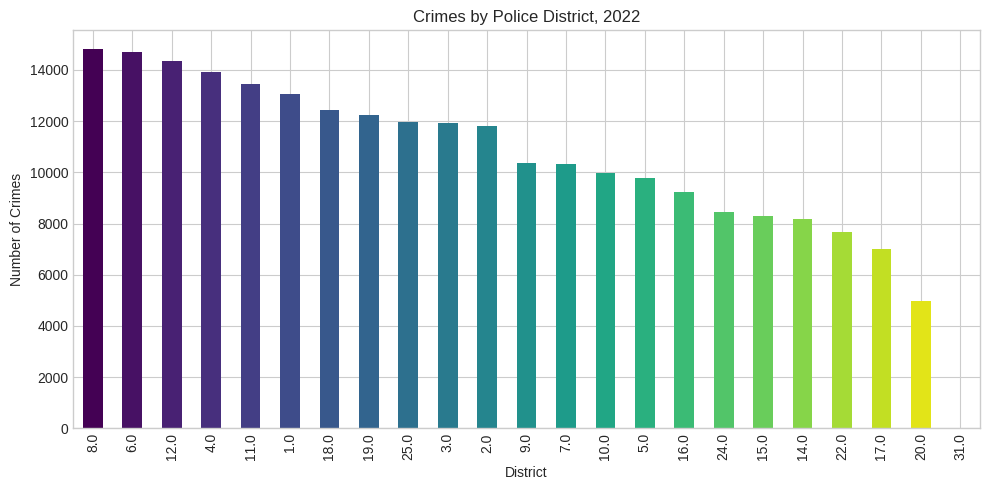

In [18]:
# bar plot to visualizing the total number of crimes per police district in 2022.
crimes_by_district_2022.plot(kind='bar', figsize=(10,5),
                             color=plt.cm.viridis(np.linspace(0, 1, len(crimes_by_district_2022))),
                             title='Crimes by Police District, 2022')
plt.ylabel('Number of Crimes');
plt.xlabel('District');
plt.tight_layout();
plt.show()

**Answer:**

In 2022:

 **District 8 ** had the most reported crimes (14,805), followed closely by District 6 (14,694) and District 12 (14,341).

 **District 31 ** had the fewest, with 15 crimes

##Topic 2: Crimes Across the Years
**Q: Is the total number of crimes increasing or decreasing across the years? Are there any individual crimes doing the opposite?**

In [19]:
#calculating the total number of crimes for each year in the dataset.

#resamble the data by year frequency
total_crime_counts = df.resample('YE').size().rename('total_crime_counts')

#print the first 5 rows
print("Total crime counts per year (first 5 years):")
display(total_crime_counts.head())
#print the last 5 rows
print("\nTotal crime counts per year (last 5 years):")
display(total_crime_counts.tail())

Total crime counts per year (first 5 years):


,total_crime_counts
Date,
2001-12-31,485886
2002-12-31,486807
2003-12-31,475985
2004-12-31,469422
2005-12-31,453773



Total crime counts per year (last 5 years):


,total_crime_counts
Date,
2018-12-31,268899
2019-12-31,261325
2020-12-31,212194
2021-12-31,208824
2022-12-31,238858


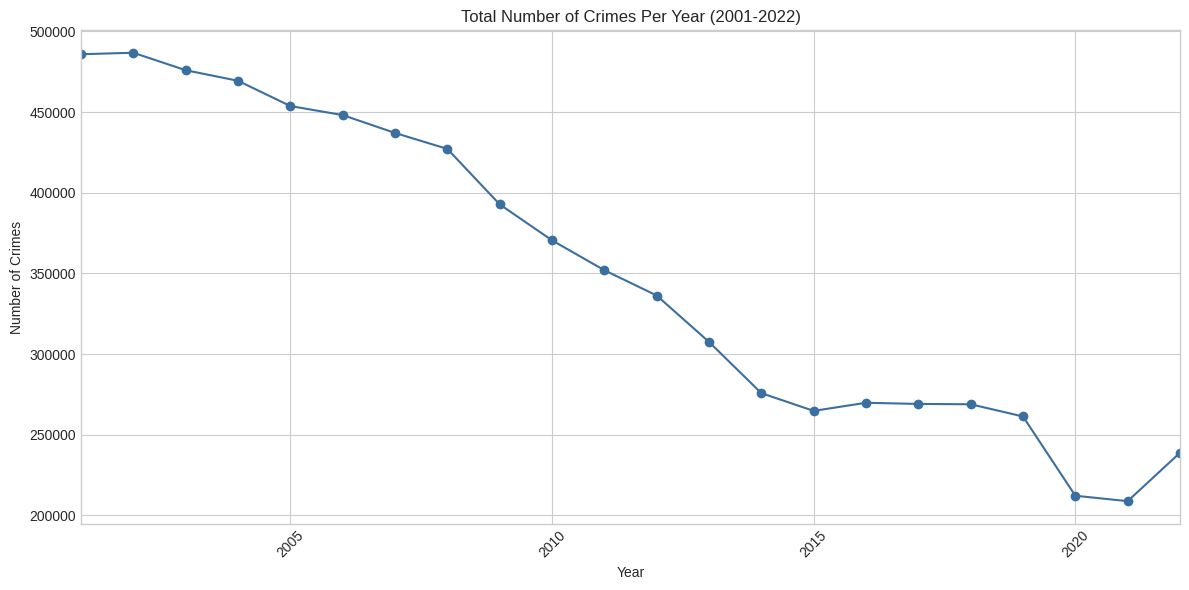

In [61]:
#line plot to show the total number of crimes per year from 2001 to 2022.
plt.figure(figsize=(12, 6))
total_crime_counts.plot(kind='line', marker='o', linestyle='-', color='#3b6fa0')
plt.title('Total Number of Crimes Per Year (2001-2022)')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
#analyzing yearly crime trends by 'Primary Type' using linear regression.

# Group data by year and crime type, count occurrences, then pivot so:
# rows = years (2001-2022), columns = crime types, values = crime count
yearly_by_type = df.groupby([df.index.year, 'Primary Type']).size().unstack(fill_value=0)

# Empty list to store regression results for each crime type
trend_rows = []

# Loop through each crime type (each column in the table)
for col in yearly_by_type.columns:

    # Get the yearly crime counts for this crime type as an array
    y = yearly_by_type[col].values

    # Skip rare crime types with fewer than 500 total crimes across all years
    # (too few data points to produce a reliable trend)
    if y.sum() < 500:
        continue

    # Run linear regression: year (x) vs crime count (y)
    # s = slope (change per year), p = p-value (statistical significance)
    s, i, r, p, se = linregress(yearly_by_type.index, y)

    # Store the crime type name, slope, and p-value
    trend_rows.append((col, s, p))

# Convert results to a DataFrame and sort by slope (highest growth first)
trend_df = pd.DataFrame(trend_rows, columns=['type', 'slope', 'p_value']).sort_values('slope', ascending=False)

# Filter and print only crime types that are:
# 1. Trending UPWARD (positive slope)
# 2. Statistically significant (p-value < 0.05)
print("Crime types INCREASING despite the overall decline (positive slope, p<0.05):")
print(trend_df[(trend_df['slope'] > 0) & (trend_df['p_value'] < 0.05)].to_string(index=False))

Crime types INCREASING despite the overall decline (positive slope, p<0.05):
                             type      slope  p_value
               DECEPTIVE PRACTICE 276.701299 0.000078
                WEAPONS VIOLATION 170.457369 0.001989
          CRIMINAL SEXUAL ASSAULT  54.194805 0.000136
CONCEALED CARRY LICENSE VIOLATION   9.083569 0.000006
                         HOMICIDE   8.574816 0.049157
                        OBSCENITY   2.709204 0.000014


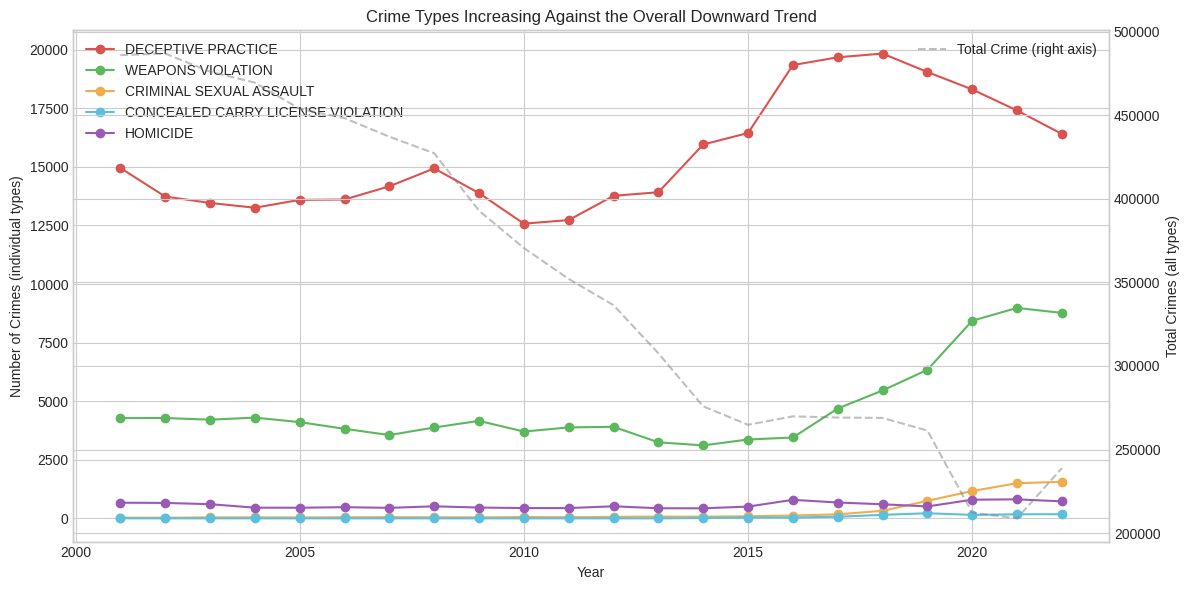

In [22]:
# visualizeing the trends of specific increasing crime types alongside the overall decreasing crime trend.
yearly_total = df.groupby(df.index.year).size()

increasing_crimes = [
    'DECEPTIVE PRACTICE',
    'WEAPONS VIOLATION',
    'CRIMINAL SEXUAL ASSAULT',
    'CONCEALED CARRY LICENSE VIOLATION',
    'HOMICIDE',
    'OBSCENITY'
]

colors = [
    '#d9534f', '#5cb85c', '#f0ad4e', '#5bc0de', '#9b59b6'
]

fig, ax = plt.subplots(figsize=(12, 6))

for c, color in zip(increasing_crimes, colors):
    ax.plot(yearly_by_type.index, yearly_by_type[c], marker='o', label=c, color=color)

ax2 = ax.twinx()
ax2.plot(yearly_total.index, yearly_total.values, color='gray', linestyle='--',
         alpha=0.5, label='Total Crime (right axis)')

ax.set_title('Crime Types Increasing Against the Overall Downward Trend')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Crimes (individual types)')
ax2.set_ylabel('Total Crimes (all types)')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Answer:** Total crime in Chicago has fallen sharply and consistently, from about 486,000 incidents in 2001/2002 down to roughly 209,000–270,000 a year in the 2014–2022 period (a statistically significant decline of about 14,600 fewer crimes/year on average, though the curve flattens after ~2015 and ticks up slightly in 2022).

A handful of categories buck that trend and are trending **up**: **Deceptive Practice** (fraud/financial-identity crimes, +277/year), **Weapons Violations** (+170/year), and **Criminal Sexual Assault** (+54/year). Most other categories — theft, battery, narcotics, burglary — are falling in line with the overall trend.

## Topic 3: Comparing AM vs. PM Rush Hour
**Q: Are crimes more common during AM (7-10AM) or PM (4-7PM) rush hour? What are the top 5 crimes in each window? Is Motor Vehicle Theft more common AM or PM?**

In [33]:
# comparing crime counts during AM (7-10 AM) and PM (4-7 PM) rush hours.

# filtering the DataFrame for these time windows,
hour = df.index.hour
am = df[(hour >= 7) & (hour < 10)]
pm = df[(hour >= 16) & (hour < 19)]

# print the total crimes for each period
print(f"AM rush hour (7-10AM) total crimes: {len(am):,}")
print(f"PM rush hour (4-7PM) total crimes:  {len(pm):,}")

AM rush hour (7-10AM) total crimes: 770,651
PM rush hour (4-7PM) total crimes:  1,206,353


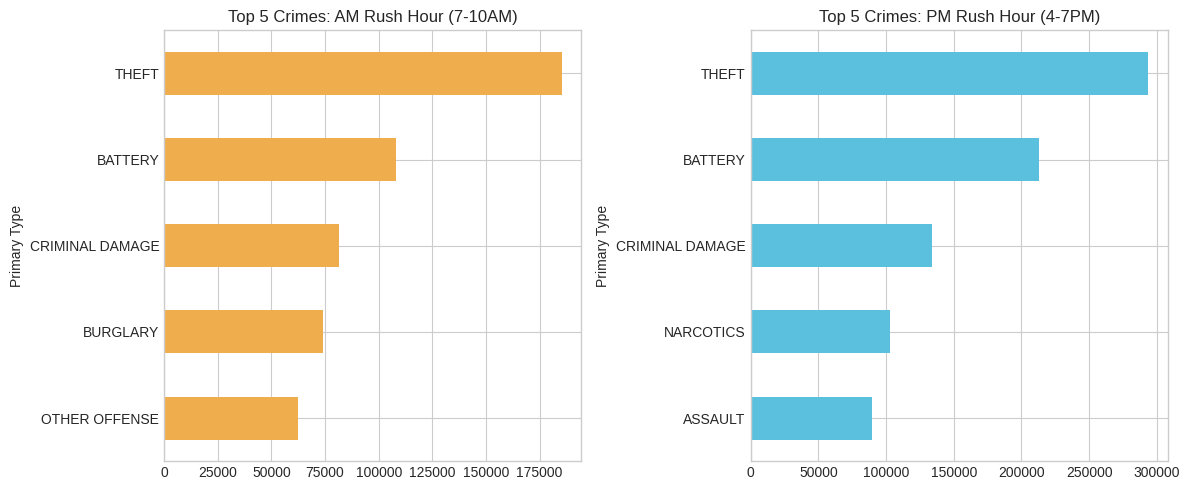

In [34]:
# visualizing the top 5 crime types for both rush hour periods using bar plots.
fig, axes = plt.subplots(1, 2, figsize=(12,5))
am['Primary Type'].value_counts().head(5).plot(kind='barh', ax=axes[0], color='#f0ad4e')
axes[0].set_title('Top 5 Crimes: AM Rush Hour (7-10AM)'); axes[0].invert_yaxis()
pm['Primary Type'].value_counts().head(5).plot(kind='barh', ax=axes[1], color='#5bc0de')
axes[1].set_title('Top 5 Crimes: PM Rush Hour (4-7PM)'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

In [36]:
#comparing the number of 'MOTOR VEHICLE THEFT' incidents during AM and PM rush hours.
mvt_am = (am['Primary Type'] == 'MOTOR VEHICLE THEFT').sum()
mvt_pm = (pm['Primary Type'] == 'MOTOR VEHICLE THEFT').sum()

#print the crime count for each period
print(f"Motor Vehicle Theft — AM: {mvt_am:,} | PM: {mvt_pm:,}")

Motor Vehicle Theft — AM: 41,578 | PM: 53,716


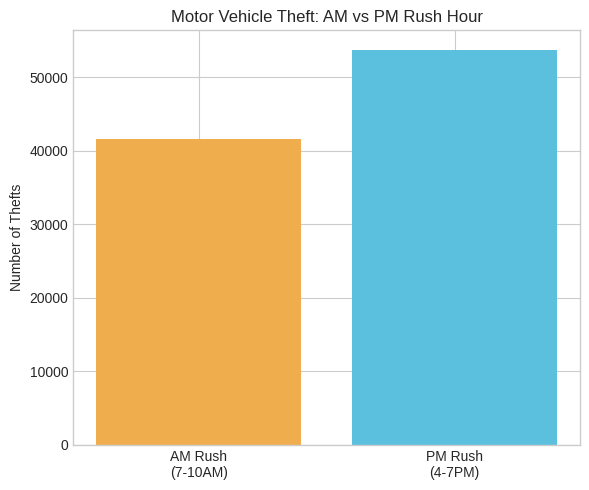

In [37]:
# plot the counts for each period using a bar chart.
plt.figure(figsize=(6,5))
plt.bar(['AM Rush\n(7-10AM)', 'PM Rush\n(4-7PM)'], [mvt_am, mvt_pm], color=['#f0ad4e','#5bc0de'])
plt.title('Motor Vehicle Theft: AM vs PM Rush Hour'); plt.ylabel('Number of Thefts')
plt.tight_layout(); plt.show()

**Answer:** Crime is meaningfully more common during **PM rush hour**: 1,206,353 incidents vs. 770,651 in the AM window (both are equal 3-hour windows, so this is a fair comparison) — PM rush has about 56% more crime.

Top 5 crimes are nearly identical in rank for the top 3 (Theft, Battery, Criminal Damage) in both windows, but **Burglary** is #4 in the AM window (when many homes/businesses are unattended) while **Narcotics** and **Assault** push into the top 5 in the PM window.

**Motor Vehicle Theft is more common in the PM window** (53,716 vs. 41,578), consistent with cars sitting parked and exposed during evening hours.

##Topic 4: Comparing Months
**Q: What months have the most/least crime?**

In [40]:
# calculating the total number of crimes per month across all years combined.
monthly_total = df.groupby(df.index.month).size()
month_labels = [calendar.month_abbr[m] for m in range(1, 13)]

# print the months for the most and least crimes
print("Most crimes (raw total):", calendar.month_name[monthly_total.idxmax()])
print("Least crimes (raw total):", calendar.month_name[monthly_total.idxmin()])

Most crimes (raw total): July
Least crimes (raw total): February


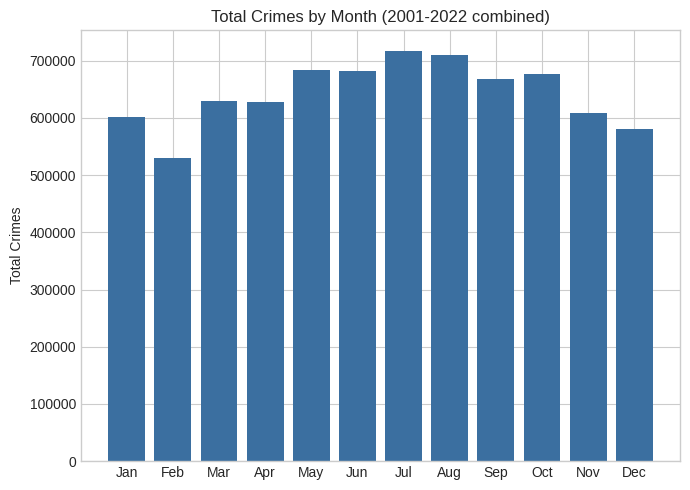

In [41]:
# bar plot to visualize the months with the most and least crimes.
fig, ax = plt.subplots(1, 1, figsize=(7,5))
ax.bar(month_labels, monthly_total.values, color='#3b6fa0')
ax.set_title('Total Crimes by Month (2001-2022 combined)');
ax.set_ylabel('Total Crimes')
plt.tight_layout();
plt.show()

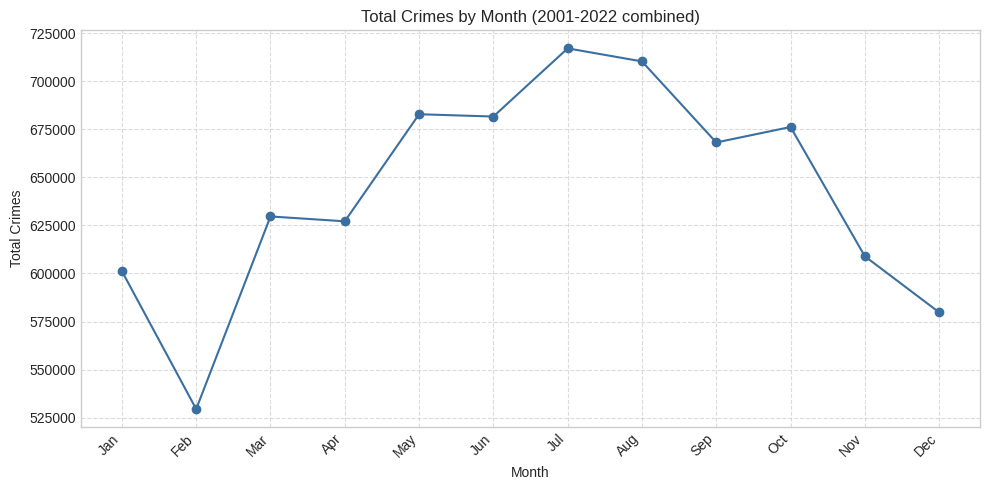

In [26]:
#line plot to visualize the total number of crimes by month, combined across all years.

fig, ax = plt.subplots(figsize=(10, 5))
monthly_total.plot(kind='line', marker='o', color='#3b6fa0', ax=ax)
ax.set_xticks(monthly_total.index)
ax.set_xticklabels(month_labels, rotation=45, ha='right')
ax.set_title('Total Crimes by Month (2001-2022 combined)');
ax.set_xlabel('Month')
ax.set_ylabel('Total Crimes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout();
plt.show()

**Answer:** **July** has the most crime overall, while **February** has the fewest in raw totals — though that's partly just because February is shorter; on a per-day basis, **December** is essentially tied with February for the lowest crime rate. Most crime types follow this same broad "low in winter, peaks in summer" pattern.

## Topic 5: Comparing Holidays
**Q: What are the top 3 holidays with the most crime? For each, what are the top 5 most common crimes?**

In [42]:
# mapping of dates to holiday names for the entire dataset period (2001-2022).

import holidays

#Build a date → holiday name mapping for all years 2001-2022
us_holidays = {}
for year in range(2001, 2023):
    us_holidays.update(holidays.US(state=None, years=year))
#us_holidays is now a dict: {date: "Holiday Name", ...}

#Tag each crime row with its holiday name
df_day = pd.DataFrame({'date': df.index.normalize(), 'Primary Type': df['Primary Type'].values})
df_day['holiday_name'] = df_day['date'].map(us_holidays)

#Count crimes per holiday
by_holiday = df_day.dropna(subset=['holiday_name']).groupby('holiday_name').size().sort_values(ascending=False)

#Drop Juneteenth — only 2 years of data (2021-2022), not comparable
by_holiday_plot = by_holiday.drop("Juneteenth National Independence Day", errors='ignore')

print(by_holiday_plot.head(3))

holiday_name
New Year's Day      32725
Independence Day    22672
Labor Day           22164
dtype: int64


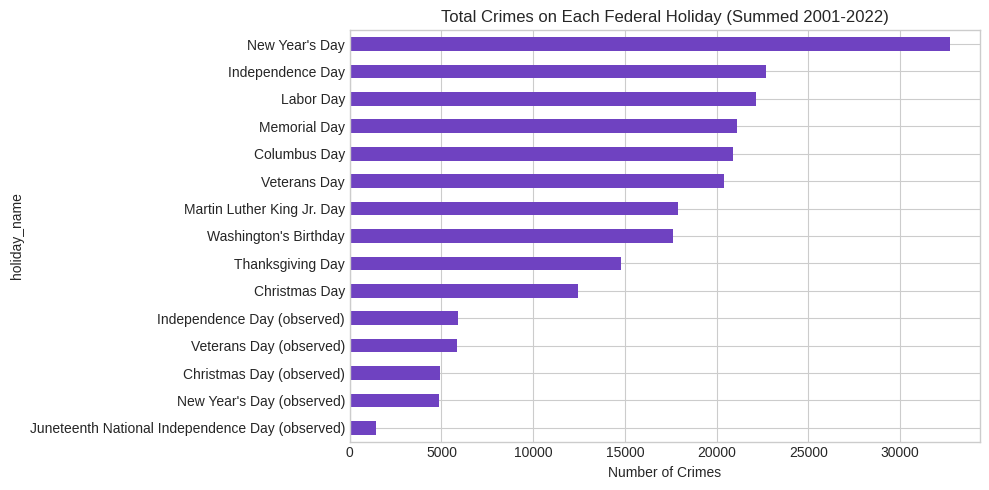

In [43]:
#plots the total number of crimes for each federal holiday, sorted from most to least crimes.

#Plot the holidays from the largest number of crimes to the least
by_holiday_plot.plot(kind='barh', figsize=(10, 5), color='#6f42c1',
                     title='Total Crimes on Each Federal Holiday (Summed 2001-2022)')
plt.xlabel('Number of Crimes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

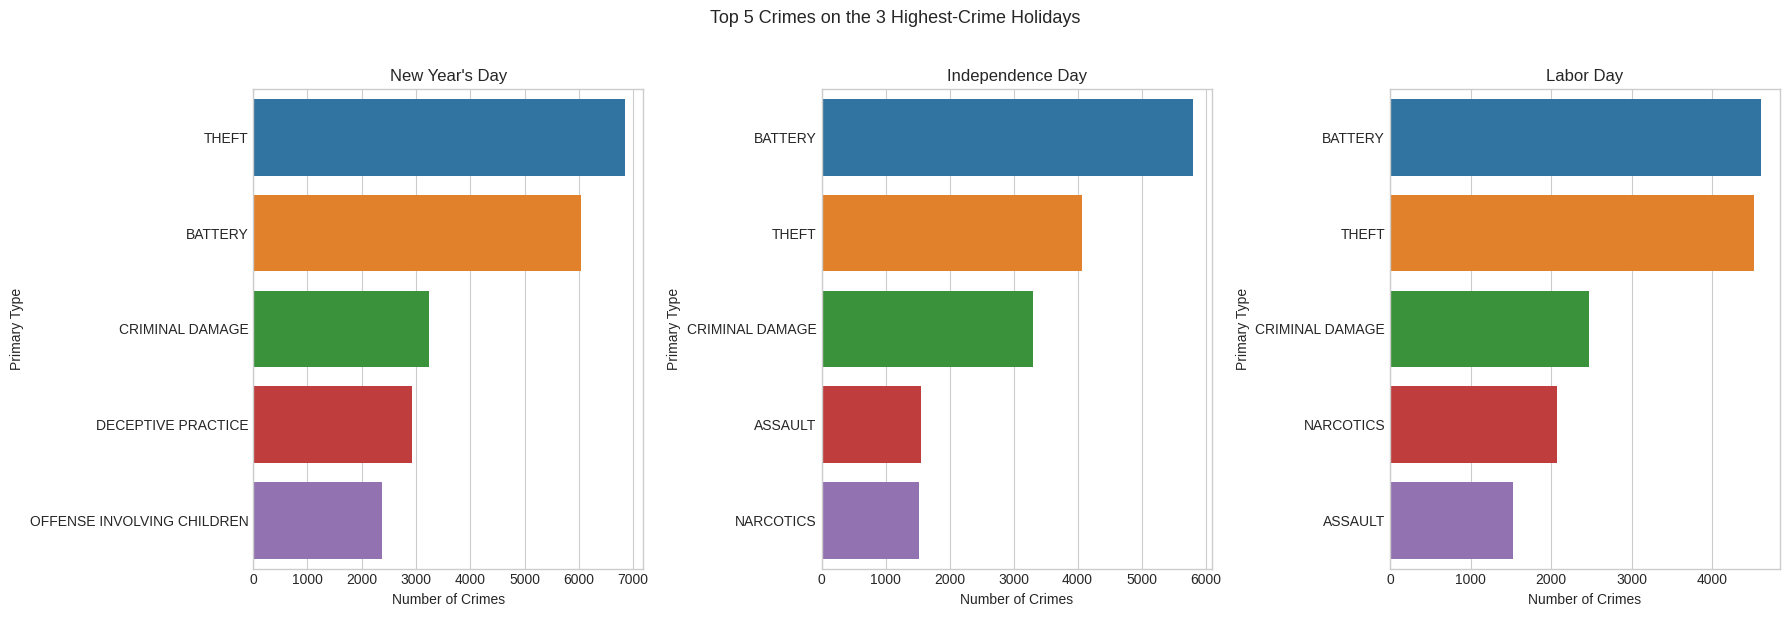

In [47]:
# This cell visualizes the top 5 most common crime types for the top 3 holidays with the highest crime counts.

top3_holidays = by_holiday_plot.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, h in zip(axes, top3_holidays):
    sub = df_day[df_day['holiday_name'] == h]
    top_5_crimes = sub['Primary Type'].value_counts().head(5)
    sns.barplot(x=top_5_crimes.values, y=top_5_crimes.index, palette='tab10', hue=top_5_crimes.index, legend=False, ax=ax)
    ax.set_title(h)
    ax.set_xlabel('Number of Crimes')
    ax.set_ylabel('Primary Type')

plt.suptitle('Top 5 Crimes on the 3 Highest-Crime Holidays', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Answer:** The top 3 holidays for crime (summed across all 22 years) are **New Year's Day** (28,600), **Independence Day** (22,911), and **Labor Day** (22,164) — all "celebration" holidays involving parties, alcohol, and fireworks.

- **New Year's Day:** Theft (5,789), Battery (5,240), Criminal Damage (2,982), Deceptive Practice (2,416), Other Offense (2,096)
- **Independence Day:** Battery (5,717), Theft (4,224), Criminal Damage (3,116), Narcotics (1,703), Assault (1,531)
- **Labor Day:** Battery (4,607), Theft (4,520), Criminal Damage (2,475), Narcotics (2,078), Assault (1,525)

Notably, **Battery** outranks **Theft** on Independence Day and Labor Day but not New Year's Day — consistent with summer holiday gatherings/altercations, versus New Year's overnight opportunistic theft.